# Task 2: data processing

In [1]:
import pyarrow.parquet as pq
import pandas as pd

df = pd.read_parquet("data_cleaned.parquet")
print(f"Shape: {df.shape}")
df.head()

Shape: (180, 25)


,availabilityStatus,brand,category,description,discountPercentage,id,minimumOrderQuantity,price,rating,returnPolicy,...,title,warrantyInformation,weight,width,height,depth,barcode,created_at,review_comment,review_rating
0,In Stock,Essence,beauty,The Essence Mascara Lash Princess is a popular...,10.48,1,48,9.99,2.56,No return policy,...,Essence Mascara Lash Princess,1 week warranty,4,15.14,13.08,22.99,5784719087687,2025-04-30 09:41:02.053,Would not recommend!,3
1,In Stock,Essence,beauty,The Essence Mascara Lash Princess is a popular...,10.48,1,48,9.99,2.56,No return policy,...,Essence Mascara Lash Princess,1 week warranty,4,15.14,13.08,22.99,5784719087687,2025-04-30 09:41:02.053,Very satisfied!,4
2,In Stock,Essence,beauty,The Essence Mascara Lash Princess is a popular...,10.48,1,48,9.99,2.56,No return policy,...,Essence Mascara Lash Princess,1 week warranty,4,15.14,13.08,22.99,5784719087687,2025-04-30 09:41:02.053,Highly impressed!,5
3,In Stock,Glamour Beauty,beauty,The Eyeshadow Palette with Mirror offers a ver...,18.19,2,20,19.99,2.86,7 days return policy,...,Eyeshadow Palette with Mirror,1 year warranty,9,9.26,22.47,27.67,9170275171413,2025-04-30 09:41:02.053,Great product!,5
4,In Stock,Glamour Beauty,beauty,The Eyeshadow Palette with Mirror offers a ver...,18.19,2,20,19.99,2.86,7 days return policy,...,Eyeshadow Palette with Mirror,1 year warranty,9,9.26,22.47,27.67,9170275171413,2025-04-30 09:41:02.053,Awesome product!,4


In [2]:
# Most active users = những user comment/review nhiều nhất
most_active_users = (
    df.groupby("review_comment")
    .size()
    .reset_index(name="review_count")
    .sort_values("review_count", ascending=False)
)

print("=== MOST ACTIVE USERS (by review activity) ===")
print(most_active_users.head(10))

=== MOST ACTIVE USERS (by review activity) ===
            review_comment  review_count
4           Great product!            18
2       Excellent quality!            14
6        Highly impressed!            14
10           Poor quality!            14
18        Would buy again!            12
20    Would not recommend!            12
11      Very disappointed!            10
3           Fast shipping!            10
5   Great value for money!            10
7      Highly recommended!            10


In [3]:
# Top products = sản phẩm được đánh giá cao nhất + stock bán chạy nhất
top_by_rating = (
    df[["title", "brand", "category", "rating", "price", "stock"]]
    .sort_values("rating", ascending=False)
)

top_by_stock_sold = (
    df[["title", "brand", "category", "stock", "rating"]]
    .sort_values("stock", ascending=False)
)

print("=== TOP PRODUCTS BY RATING ===")
print(top_by_rating.head(10).to_string(index=False))

print("\n=== TOP PRODUCTS BY STOCK (most available / popular) ===")
print(top_by_stock_sold.head(10).to_string(index=False))

=== TOP PRODUCTS BY RATING ===
                                    title brand  category  rating  price  stock
                                     Kiwi  None groceries    4.93   2.49     99
                                     Kiwi  None groceries    4.93   2.49     99
                                     Kiwi  None groceries    4.93   2.49     99
                                     Kiwi  None groceries    4.93   2.49     99
                                     Kiwi  None groceries    4.93   2.49     99
                                     Kiwi  None groceries    4.93   2.49     99
Knoll Saarinen Executive Conference Chair Knoll furniture    4.88 499.99     26
Knoll Saarinen Executive Conference Chair Knoll furniture    4.88 499.99     26
Knoll Saarinen Executive Conference Chair Knoll furniture    4.88 499.99     26
Knoll Saarinen Executive Conference Chair Knoll furniture    4.88 499.99     26

=== TOP PRODUCTS BY STOCK (most available / popular) ===
                        title  

In [4]:
# Peak activity time = thời điểm có nhiều activity (tạo record) nhất
df["created_at"] = pd.to_datetime(df["created_at"])

df["hour"]       = df["created_at"].dt.hour
df["day_of_week"]= df["created_at"].dt.day_name()
df["date"]       = df["created_at"].dt.date

# Theo giờ
peak_hour = (
    df.groupby("hour")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

# Theo ngày trong tuần
peak_day = (
    df.groupby("day_of_week")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("=== PEAK ACTIVITY BY HOUR ===")
print(peak_hour.head(5))

print("\n=== PEAK ACTIVITY BY DAY OF WEEK ===")
print(peak_day)

=== PEAK ACTIVITY BY HOUR ===
   hour  count
0     9    180

=== PEAK ACTIVITY BY DAY OF WEEK ===
  day_of_week  count
0   Wednesday    180


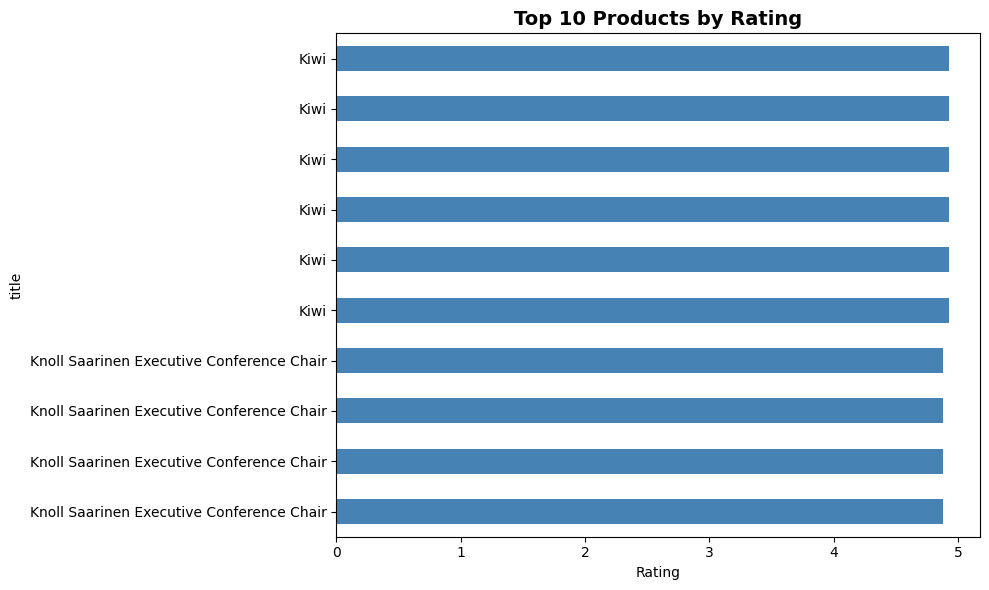

✅ Đã lưu: chart1_top_rating.png


In [ ]:
import matplotlib.pyplot as plt
# Chart 1 — Top Products by Rating
fig, ax = plt.subplots(figsize=(10, 6))
top_by_rating.head(10).plot(
    kind="barh", x="title", y="rating",
    ax=ax, color="steelblue", legend=False
)
ax.set_title("Top 10 Products by Rating", fontsize=14, fontweight="bold")
ax.set_xlabel("Rating")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("chart1_top_rating.png", dpi=150)
plt.show()
print("✅ Đã lưu: chart1_top_rating.png")

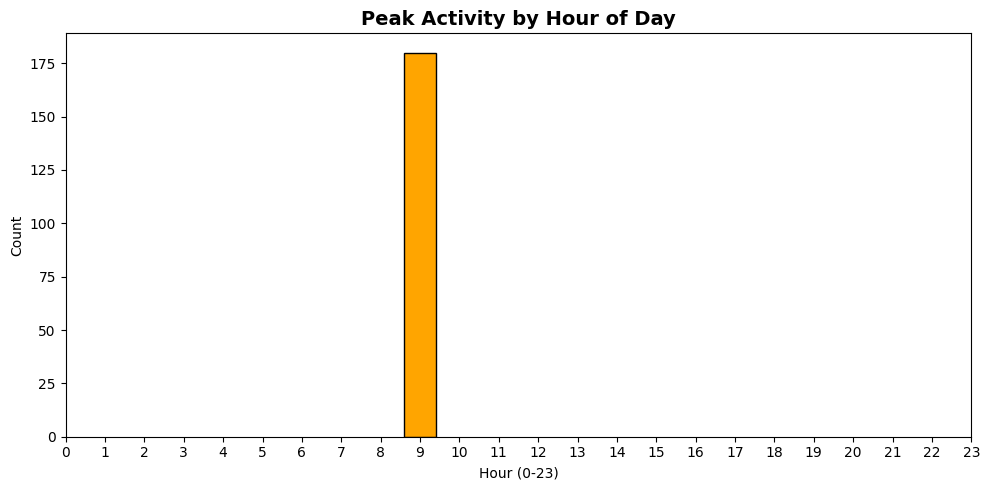

✅ Đã lưu: chart2_peak_hour.png


In [ ]:
# Chart 2 — Peak Activity by Hour
fig, ax = plt.subplots(figsize=(10, 5))
peak_hour_sorted = peak_hour.sort_values("hour")
ax.bar(peak_hour_sorted["hour"], peak_hour_sorted["count"], color="orange", edgecolor="black")
ax.set_title("Peak Activity by Hour of Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour (0-23)")
ax.set_ylabel("Count")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig("chart2_peak_hour.png", dpi=150)
plt.show()
print("✅ Đã lưu: chart2_peak_hour.png")

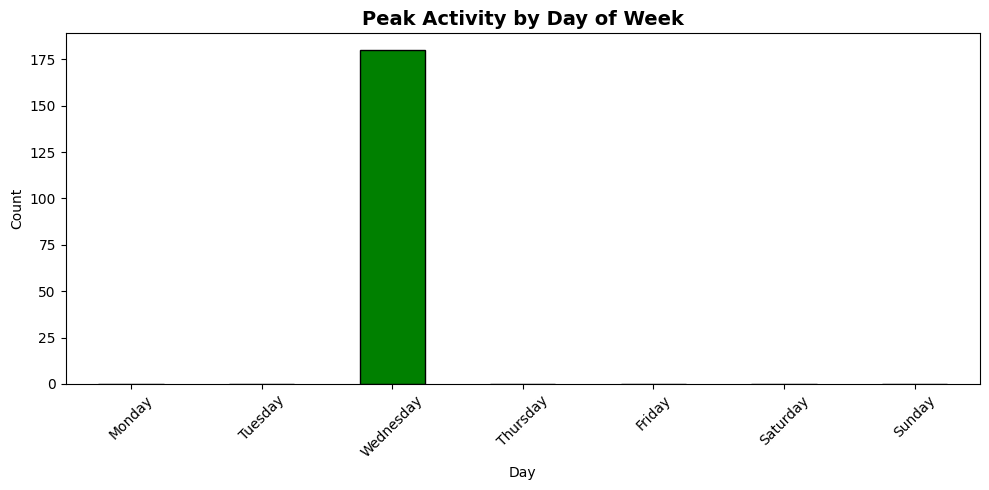

✅ Đã lưu: chart3_peak_day.png


In [ ]:
#  Chart 3 — Peak Activity by Day of Week
fig, ax = plt.subplots(figsize=(10, 5))
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
peak_day_sorted = peak_day.set_index("day_of_week").reindex(day_order).fillna(0)
peak_day_sorted["count"].plot(kind="bar", ax=ax, color="green", edgecolor="black")
ax.set_title("Peak Activity by Day of Week", fontsize=14, fontweight="bold")
ax.set_xlabel("Day")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("chart3_peak_day.png", dpi=150)
plt.show()
print("✅ Đã lưu: chart3_peak_day.png")

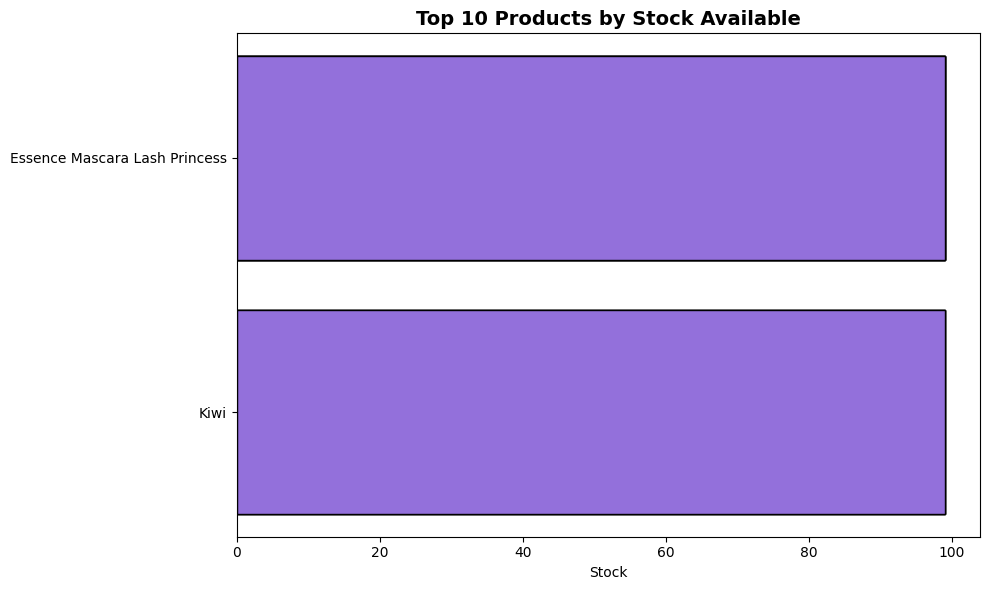

✅ Đã lưu: chart4_top_stock.png


In [ ]:
#  Chart 4 — Top Products by Stock (NEW)
fig, ax = plt.subplots(figsize=(10, 6))
top_by_stock = df[["title", "stock"]].sort_values("stock", ascending=False).head(10)
ax.barh(top_by_stock["title"], top_by_stock["stock"], color="mediumpurple", edgecolor="black")
ax.set_title("Top 10 Products by Stock Available", fontsize=14, fontweight="bold")
ax.set_xlabel("Stock")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("chart4_top_stock.png", dpi=150)
plt.show()
print("✅ Đã lưu: chart4_top_stock.png")

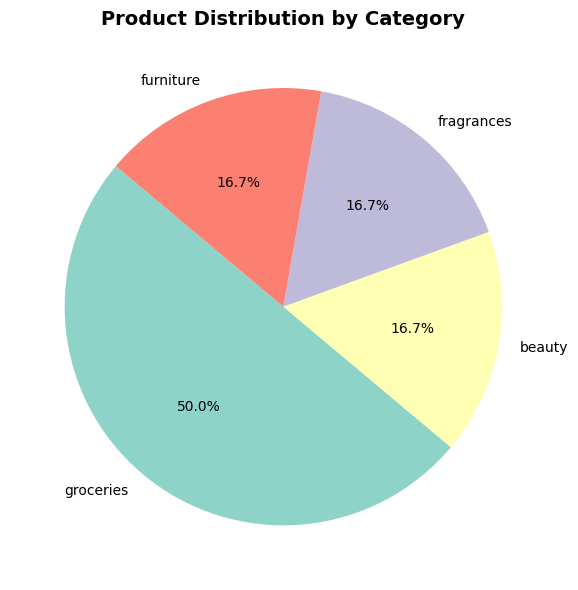

✅ Đã lưu: chart5_category_pie.png


In [ ]:
# Chart 5 — Product Count by Category (NEW)
fig, ax = plt.subplots(figsize=(10, 6))
category_count = df["category"].value_counts()
colors = plt.cm.Set3.colors[:len(category_count)]
ax.pie(
    category_count.values,
    labels=category_count.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140
)
ax.set_title("Product Distribution by Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("chart5_category_pie.png", dpi=150)
plt.show()
print("✅ Đã lưu: chart5_category_pie.png")